In [1]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [2]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [3]:
compact = True

In [4]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(os.path.join(data_dir, f"combined_{timestamp}.parquet"))

    # Move files already in trash to trash within trash
    trash = os.path.join(data_dir, "trash")
    trash_in_trash = os.path.join(trash, f"trash_{timestamp}")
    os.makedirs(trash_in_trash, exist_ok=True)
    for f in os.listdir(trash):
        if f.endswith(".parquet") or f.endswith(".csv"):
            os.rename(os.path.join(trash, f), os.path.join(trash_in_trash, f))
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading combined_20240908141615.parquet
Reading 2024-09-14_17-36-32.parquet
Reading 2024-09-15_09-09-44.parquet
Reading 2024-09-15_09-23-53.parquet
Reading 2024-09-14_17-23-58.parquet
Reading 2024-09-15_09-11-59.parquet
Reading 2024-09-08_14-18-39.parquet
Reading 2024-09-15_09-30-38.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,...,player_type,opponent_names,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,,
d7017fec-1c32-4005-9cdd-f94e9ea28417,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,16,0.5003,0.015009,0,"[11, 0, 0, 0, 0]",608.0,NaN
9e6087b9-6d79-4b90-9302-849d7b328ba5,d7017fec-1c32-4005-9cdd-f94e9ea28417,"[41, 31, 17]","[82, 82]",0,"[0, 0]","[18, 18]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.3218,0.057924,0,"[11, 5, 4, 2, 0]",608.0,NaN
29ccf1f9-4e29-4a1d-88bc-53be9a34e3f4,9e6087b9-6d79-4b90-9302-849d7b328ba5,"[41, 31, 17, 23]","[82, 82]",0,"[0, 0]","[18, 18]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,82,0.2672,0.048096,0,"[11, 10, 5, 4, 2]",608.0,NaN
d2fb7009-21a3-4e30-8f67-b91e44aea81b,29ccf1f9-4e29-4a1d-88bc-53be9a34e3f4,"[41, 31, 17, 23, 15]","[0, 0]",0,"[0, 0]","[100, 100]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.2959,0.295900,1,"[2, 11, 10, 5, 0]",608.0,NaN
4be4b289-7768-4376-8273-d07c7904fbca,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,2,0.4719,0.014157,0,"[6, 1, 0, 0, 0]",1030.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
e29ab61d-2f89-474e-b750-f4ab6620e9d9,e9798fc4-04f6-4bec-b723-985831571e6c,"[3, 12, 20]","[30, 154]",0,"[0, 0]","[8, 8]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.7515,0.060120,1,"[7, 12, 11, 3, 0]",969.0,NaN
752da045-ffdd-4a9b-ac86-a03578d27c8a,e29ab61d-2f89-474e-b750-f4ab6620e9d9,"[3, 12, 20]","[30, 147]",0,"[0, 7]","[8, 15]","[True, True]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,7,0.7515,0.086423,1,"[7, 12, 11, 3, 0]",969.0,NaN
bacb48ca-872f-4b5b-a0e2-86158735e135,752da045-ffdd-4a9b-ac86-a03578d27c8a,"[3, 12, 20, 50]","[23, 147]",0,"[0, 0]","[15, 15]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,10,0.9293,0.139395,2,"[11, 7, 12, 0, 0]",969.0,NaN


In [5]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
opponent_names        object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [6]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [7]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,game_id,action,amount,excess_rank,p,relative_ev,stage,player_name,opponent_name,n_players
6139425600,0,0,0,0,0,0,0,0,0,0,...,947aa6cb-1372-41c8-b92f-7575d348e346,check,0,0,0.62710,0.025084,preflop,Tord,,2
1d28cc81-1e08-4660-a34a-e2d406722085,0,0,0,0,0,0,0,0,0,0,...,ae434779-322d-4a7f-be8a-6bd479ddcc67,check,0,0,0.54330,0.021732,preflop,Tord,,2
6087756864,0,0,0,0,0,0,0,0,0,0,...,e06523b4-dd51-46a0-b4af-d0a2b1fb039d,call,2,0,0.54259,0.016278,preflop,Arin,,2
3d4d5c4c-3f76-4db4-a959-aa184e3504ab,0,0,0,0,0,0,0,0,0,0,...,c570a8be-2159-4f61-9a64-e10eb4e1543f,call,2,0,0.62900,0.018870,preflop,t,Max Mekker,2
6097660512,0,0,0,0,0,0,0,0,0,0,...,9884e8b6-4195-4256-9a80-8fd8b85466d6,fold,0,0,0.52893,0.015868,preflop,Arin,,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65198114-ef6e-4915-8973-dfb408b0188e,0,6,40,0,0,6,7,4,0,0,...,dda9adfb-2964-44d2-bacd-13c97d0e208c,call,29,0,0.09270,0.073696,river,Jacob,Max Mekker,2
6103987440,0,0,48,0,0,4,5,0,0,0,...,295b3f94-98d8-460a-9466-008ac8c069a3,raise,8,2,0.85510,0.538713,turn,Arin,,2
6172605696,0,0,56,0,0,4,5,0,0,0,...,295b3f94-98d8-460a-9466-008ac8c069a3,raise,16,2,0.85510,0.641325,turn,Arin,,2
10963606496,0,0,72,0,0,4,5,0,0,0,...,295b3f94-98d8-460a-9466-008ac8c069a3,raise,10,2,0.85510,0.752488,turn,Arin,,2


In [8]:
df.dtypes

raise_preflop                int64
raise_flop                   int64
raise_turn                   int64
raise_river                  int64
raise_showdown               int64
call_preflop                 int64
call_flop                    int64
call_turn                    int64
call_river                   int64
call_showdown                int64
check_preflop                int64
check_flop                   int64
check_turn                   int64
check_river                  int64
check_showdown               int64
opponent_raise_preflop       int64
opponent_raise_flop          int64
opponent_raise_turn          int64
opponent_raise_river         int64
opponent_raise_showdown      int64
opponent_call_preflop        int64
opponent_call_flop           int64
opponent_call_turn           int64
opponent_call_river          int64
opponent_call_showdown       int64
opponent_check_preflop       int64
opponent_check_flop          int64
opponent_check_turn          int64
opponent_check_river

## Training

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [10]:
X = df.drop(["excess_rank", "game_id", "p", "relative_ev"], axis=1)
y = df["p"]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [11]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,opponent_check_flop,opponent_check_turn,opponent_check_river,opponent_check_showdown,action,amount,stage,player_name,opponent_name,n_players
6139425600,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,check,0,preflop,Tord,,2
1d28cc81-1e08-4660-a34a-e2d406722085,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,check,0,preflop,Tord,,2
6087756864,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,Arin,,2
3d4d5c4c-3f76-4db4-a959-aa184e3504ab,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,t,Max Mekker,2
6097660512,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,fold,0,preflop,Arin,,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65198114-ef6e-4915-8973-dfb408b0188e,0,6,40,0,0,6,7,4,0,0,...,1,1,1,0,call,29,river,Jacob,Max Mekker,2
6103987440,0,0,48,0,0,4,5,0,0,0,...,0,0,0,0,raise,8,turn,Arin,,2
6172605696,0,0,56,0,0,4,5,0,0,0,...,0,0,0,0,raise,16,turn,Arin,,2
10963606496,0,0,72,0,0,4,5,0,0,0,...,0,0,0,0,raise,10,turn,Arin,,2


In [12]:
y

6139425600                              0.62710
1d28cc81-1e08-4660-a34a-e2d406722085    0.54330
6087756864                              0.54259
3d4d5c4c-3f76-4db4-a959-aa184e3504ab    0.62900
6097660512                              0.52893
                                         ...   
65198114-ef6e-4915-8973-dfb408b0188e    0.09270
6103987440                              0.85510
6172605696                              0.85510
10963606496                             0.85510
6172461376                              0.61730
Name: p, Length: 6295, dtype: float64

In [13]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = ["action", "stage", "player_name", "opponent_name"]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [14]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5054, 36)
Test shape: (1241, 36)


In [15]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor', LinearRegression())])

In [16]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.16328215802220122
MAE: 0.12477247160222137
MAPE: 37.62%


,y_test,y_pred
6165441360,0.52250,0.410856
a15e437a-932f-498d-83f6-93bbc0668a32,0.64390,0.561323
3b906f11-4c2d-4581-b043-87538ddbedf5,0.53990,0.396296
6327562000,0.50499,0.456352
6127311072,0.36840,0.513378
...,...,...
6107178608,0.10650,0.503457
6090899072,0.49510,0.543632
8f305c7d-dc01-4167-b676-e61abe11cf76,0.34770,0.331157
ed1efcec-254d-4356-a88b-0f41f6970ba6,0.53280,0.579874


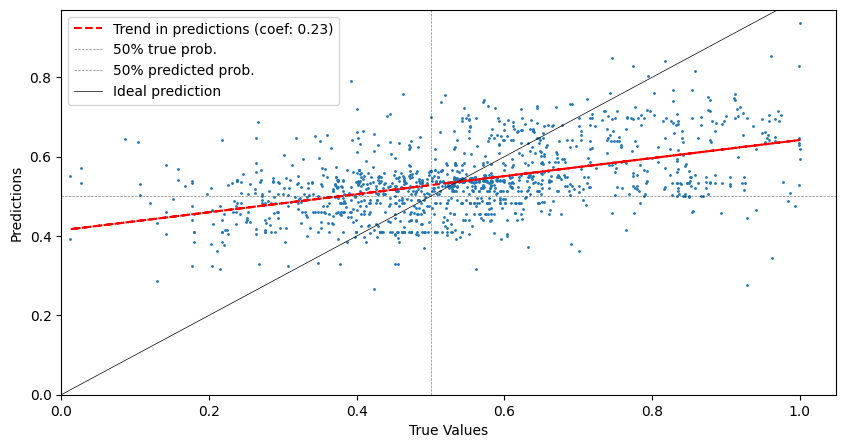

In [17]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()

### Examine feature importance

In [18]:
# Calculate feature importance
# Get the one-hot encoded feature names
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names, X.columns[len(categorical_cols):]])

coefs = model.named_steps["regressor"].coef_

# Sort by absolute value
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)
coef_df

,feature,coef,abs_coef
14,raise_showdown,-5.164664e+10,5.164664e+10
34,opponent_call_showdown,5.164664e+10,5.164664e+10
16,call_flop,7.330167e+09,7.330167e+09
36,opponent_check_flop,-7.330167e+09,7.330167e+09
37,opponent_check_turn,3.286387e+09,3.286387e+09
17,call_turn,-3.286387e+09,3.286387e+09
15,call_preflop,2.626249e+09,2.626249e+09
35,opponent_check_preflop,-2.626249e+09,2.626249e+09
18,call_river,-1.614554e+09,1.614554e+09
24,check_showdown,-1.255961e+09,1.255961e+09


### Compare to XGBoost

In [19]:
from xgboost import XGBRegressor

# Create the full pipeline with XGBoost
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "regressor",
            XGBRegressor(
                colsample_bytree=0.6,
                learning_rate=0.1,
                max_depth=3,
                n_estimators=500,
                subsample=1.0,
            ),
        ),
    ]
)

In [20]:
cross_validate = False

In [21]:
if cross_validate:
    # Cross validate to find good hyperparameters
    from sklearn.model_selection import GridSearchCV

    # Define the parameter grid
    param_grid = {
        'regressor__n_estimators': [100, 500],
        'regressor__learning_rate': [0.01, 0.1],
        'regressor__max_depth': [3, 5, 7],
        'regressor__subsample': [0.6, 0.8, 1.0],
        'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    }

    # Grid search over the XGBRegressor parameters
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Best parameters and score
    print(grid_search.best_params_)
    print(grid_search.best_score_)
    
    # Use the best model
    model = grid_search.best_estimator_

In [22]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.6, device=None,
                              early_stopping_rounds=None,
                              e...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [26]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df["player_name"] = df.iloc[test_idx]["player_name"]
pred_df

RMSE: 0.16499635473889893
MAE: 0.12195768085136517
MAPE: 36.78%


,y_test,y_pred,player_name
6165441360,0.52250,0.427328,Arin
a15e437a-932f-498d-83f6-93bbc0668a32,0.64390,0.570977,Jacob
3b906f11-4c2d-4581-b043-87538ddbedf5,0.53990,0.408162,t
6327562000,0.50499,0.482218,Tord
6127311072,0.36840,0.498724,Tord
...,...,...,...
6107178608,0.10650,0.646782,Arin
6090899072,0.49510,0.498967,Arin
8f305c7d-dc01-4167-b676-e61abe11cf76,0.34770,0.497667,Tord
ed1efcec-254d-4356-a88b-0f41f6970ba6,0.53280,0.592637,Tord


In [45]:
pred_df["square"] = (pred_df["y_test"] - pred_df["y_pred"])**2
(pred_df.pivot_table("square", "player_name", aggfunc="mean")**(1/2)).sort_values(by="square")

,square
player_name,
Finn,0.138651
t,0.155834
Tord,0.161666
Jacob,0.166950
Alun,0.169029
Arin,0.171177
Arin Bavian,0.180132


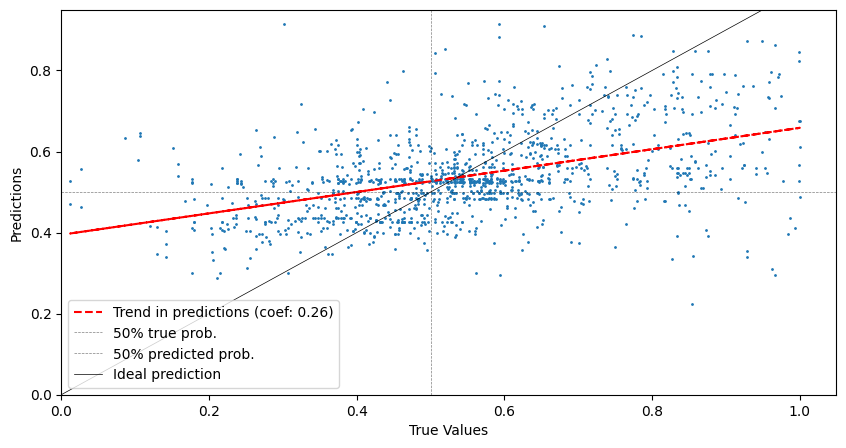

In [24]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()